In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# chargeons notre dataset
df = pd.read_csv("../data/healthcare-dataset-stroke-data.csv")
display(df.head())

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
# nous allons faire un rapide aperçu pour se rassurer que les données sont identiques
df.shape

(5110, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [6]:
# nous savons déja que la colonne bmi a 201 données manquantes
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

### Nous allons réfléchir ce que nous ferons de nos données manquantes
pour cela nous nous poserons quelques questions:
- pourquoi nous avons les valeurs manquantes dans cette variable ?
- ces valeurs manquantes ont une représentation forte ou une faible proportion du jeu de données?
- quelle méthode d'imputation est la plus adaptée?

In [11]:
#proportion des valeurs manquantes
(df.isnull().sum()/len(df)*100).round(2)

id                   0.00
gender               0.00
age                  0.00
hypertension         0.00
heart_disease        0.00
ever_married         0.00
work_type            0.00
Residence_type       0.00
avg_glucose_level    0.00
bmi                  3.93
smoking_status       0.00
stroke               0.00
dtype: float64

Le taux de valeurs manquantes (3.93%) est faible moins de 5 %. 
Notre variable présente un faible pourcentage de valeurs manquantes et elle est importante pour les analyses futures, on va privilégier généralement l'imputation plutôt que la suppression des lignes.

In [ ]:
# nous allons observer la distribution des valeurs de bmi
df["bmi"].describe()

count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

On peut constater que:
la Moyenne de l'imc de notre échantillon est 28.89
une médiane de 28.1
avec 75% des patients qui ne dépassent pas une IMC  de 33.1
avec des patients qui vont jusqu'à 97.6

In [21]:
df["bmi"].median()

np.float64(28.1)

Avant de choisir entre la moyenne, la médiane ou une autre méthode, nous devons comprendre la distribution de l'IMC.

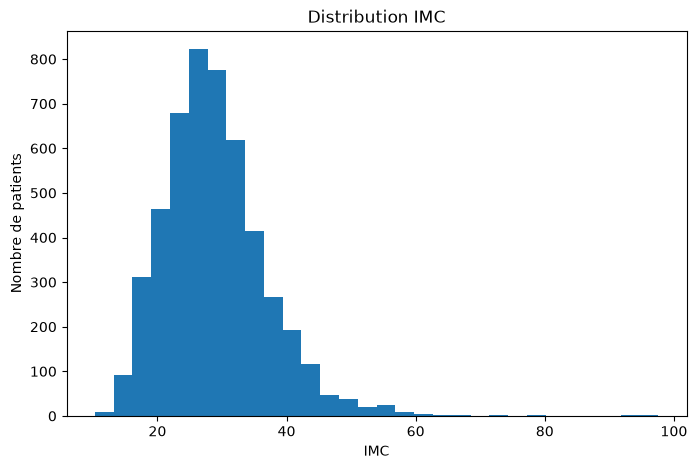

In [20]:
plt.figure(figsize=(8,5))
plt.hist(df["bmi"].dropna(), bins=30)
plt.title("Distribution IMC")
plt.xlabel("IMC")
plt.ylabel("Nombre de patients")
plt.show()

Notre distribution nous montre que:
la majorité des patients ont un IMC compris entre 20 et 35, 
la distribution présente une asymétrie vers la droite, 
quelques patients ont des IMC très élevés (jusqu'à 97,6), qui sont des valeurs extrêmes.

Nous allons donc pratiquer l'imputation par la médiane.

In [22]:
# nous allons faire une copie de notre dataset
df_clean = df.copy()


In [23]:
# Imputation des valeurs manquantes de l'IMC par la médiane
df_clean["bmi"] = df_clean["bmi"].fillna(df_clean["bmi"].median())
# vérifions la complétude des valeurs manquantes
df_clean.isna().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Notre variable bmi est complète.
Nous allons voir ce que nous ferons actuellement de la variable id, de la donnée Unkowns dans smoking_status et Other dans gender

In [25]:
df_clean.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')

In [ ]:
df_clean['id'].head() # cette variable n'est pas indicative dans le risque d'AVC nous allons donc la supprimer
                     # elle est là plus à titre technique et de traçabilité des patients

0     9046
1    51676
2    31112
3    60182
4     1665
Name: id, dtype: int64

In [ ]:
# nous allons supprimer la colonne 'id'
df_clean = df_clean.drop(columns='id')
# vérifions
df_clean.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')

In [ ]:
# traitons la variable gender
df_clean["gender"].value_counts() # nous avons qu'un patient dans le groupe Other
                                  # je pense qu'elle n'aura aucun impact significatif (il y'a qu'une seule personne) dans notre echantillon
                                    # nous allons l'exclure 

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [33]:
# exclure la personne de genre Other
df_clean = df_clean[df_clean["gender"] != "Other"]
# vérifions
df_clean["gender"].value_counts()


gender
Female    2994
Male      2115
Name: count, dtype: int64

La donnée Unknows de notre variable smoking_status sera conservée car comme nous l'allions observer lors de l'exploration, elle représente 30% de notre variable et elle dit "qu'on ne connait pas le status tabagisme du patient". C'est une information utile et pertinente.

In [47]:
# vérifions que notre df_clean est clean lolpr
print ("Dimension de départ :", df.shape)
print("Dimension après nettoyage :", df_clean.shape)

print("\nValeurs manquantes : ")

print(df_clean.isna().sum())

print("\nTypes de nos variables : ")

print(df_clean.dtypes)

Dimension de départ : (5110, 12)
Dimension après nettoyage : (5109, 11)

Valeurs manquantes : 
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Types de nos variables : 
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object


In [ ]:
# nosu allons sauvegarder notre df_clean pour l'utiliser pour la suite de nos analyses et pour Power BI
df_clean.to_csv("../data/healthcare_stroke_dataset_clean.csv", index=False)